# Bonus Part. Face Expression Recognition + Dimensionality Reduction

## Цель

Использовать датасет **Face Expression Recognition Dataset**, обучить модель снижения размерности на представлениях лиц и попробовать преобразовать:

- грустное лицо → улыбающееся лицо;
- улыбающееся лицо → грустное лицо.

Идея преобразования в латентном пространстве:

$$
z_{sad\to happy}
=
z_{sad}
-
\mu_{sad}
+
\mu_{happy}
$$

и наоборот:

$$
z_{happy\to sad}
=
z_{happy}
-
\mu_{happy}
+
\mu_{sad}
$$

где:

- `z` — low-dimensional representation лица;
- `μ_sad` — среднее представление грустных лиц;
- `μ_happy` — среднее представление улыбающихся лиц.

После изменения представления выполняется обратное преобразование в пространство изображений.


## Датасет

По условию bonus используется:

**Face Expression Recognition Dataset**

Источник указан в официальном задании проекта.

Ожидаемая структура после распаковки:

```text
face-expression-recognition-dataset/
└── images/
    ├── train/
    │   ├── angry/
    │   ├── disgust/
    │   ├── fear/
    │   ├── happy/
    │   ├── neutral/
    │   ├── sad/
    │   └── surprise/
    │
    └── validation/
        ├── angry/
        ├── disgust/
        ├── fear/
        ├── happy/
        ├── neutral/
        ├── sad/
        └── surprise/
```

Для эксперимента используются только классы:

- `sad`;
- `happy`.



In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Размер изображения оставляем стандартным для этого датасета.
IMAGE_SIZE = (48, 48)

# Количество изображений каждого класса для эксперимента.
# Можно увеличить после успешного запуска.
N_PER_CLASS = 1000

# Размерность латентного пространства.
N_COMPONENTS = 100

SAD_CLASS = "sad"
HAPPY_CLASS = "happy"

print("Параметры эксперимента готовы.")


Параметры эксперимента готовы.


# 1. Поиск датасета

Ноутбук поддерживает несколько распространённых вариантов расположения данных.


In [2]:
DATA_CANDIDATES = [
    Path("data/Face_Expression_Recognition"),
    Path("../data/Face_Expression_Recognition"),
    Path("../../data/Face_Expression_Recognition"),
    Path("data/face-expression-recognition-dataset"),
    Path("../data/face-expression-recognition-dataset"),
    Path("../../data/face-expression-recognition-dataset"),
]

DATASET_DIR = None

for candidate in DATA_CANDIDATES:
    train_candidate = candidate / "images" / "train"
    if train_candidate.exists():
        DATASET_DIR = candidate
        break

if DATASET_DIR is None:
    raise FileNotFoundError(
        "Не найден Face Expression Recognition Dataset. "
        "Положи распакованный датасет в data/Face_Expression_Recognition/"
    )

TRAIN_DIR = DATASET_DIR / "images" / "train"

print("Датасет:", DATASET_DIR.resolve())
print("Train:", TRAIN_DIR.resolve())


Датасет: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\Face_Expression_Recognition
Train: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\Face_Expression_Recognition\images\train


# 2. Проверка классов и количества изображений

In [3]:
sad_dir = TRAIN_DIR / SAD_CLASS
happy_dir = TRAIN_DIR / HAPPY_CLASS

if not sad_dir.exists():
    raise FileNotFoundError(f"Не найден класс: {sad_dir}")

if not happy_dir.exists():
    raise FileNotFoundError(f"Не найден класс: {happy_dir}")

def get_image_files(directory):
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted(
        path for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in extensions
    )

sad_files = get_image_files(sad_dir)
happy_files = get_image_files(happy_dir)

print("Sad images:", len(sad_files))
print("Happy images:", len(happy_files))


Sad images: 4938
Happy images: 7164


# 3. Функция загрузки и подготовки изображений

Каждое лицо:

1. переводится в grayscale;
2. приводится к размеру `48×48`;
3. нормализуется в диапазон `[0, 1]`;
4. разворачивается в вектор из `48×48 = 2304` признаков.


In [4]:
def load_face(path: Path):
    image = Image.open(path).convert("L")
    image = image.resize(IMAGE_SIZE, Image.Resampling.BILINEAR)

    array = np.asarray(image, dtype=np.float32) / 255.0

    return array


def image_to_vector(image):
    return image.reshape(-1)


def vector_to_image(vector):
    return np.clip(
        vector.reshape(IMAGE_SIZE),
        0,
        1,
    )


# 4. Формируем сбалансированную выборку

Используем одинаковое количество sad и happy изображений, чтобы средние представления классов не были смещены из-за разного количества образцов.


In [5]:
rng = np.random.default_rng(RANDOM_STATE)

n = min(
    N_PER_CLASS,
    len(sad_files),
    len(happy_files),
)

selected_sad_files = list(
    rng.choice(sad_files, size=n, replace=False)
)

selected_happy_files = list(
    rng.choice(happy_files, size=n, replace=False)
)

print("Используем sad:", len(selected_sad_files))
print("Используем happy:", len(selected_happy_files))


Используем sad: 1000
Используем happy: 1000


In [6]:
sad_images = np.stack(
    [load_face(path) for path in selected_sad_files]
)

happy_images = np.stack(
    [load_face(path) for path in selected_happy_files]
)

sad_vectors = sad_images.reshape(len(sad_images), -1)
happy_vectors = happy_images.reshape(len(happy_images), -1)

X_faces = np.vstack([
    sad_vectors,
    happy_vectors,
])

y_faces = np.array(
    ["sad"] * len(sad_vectors)
    + ["happy"] * len(happy_vectors)
)

print("Sad matrix:", sad_vectors.shape)
print("Happy matrix:", happy_vectors.shape)
print("Combined matrix:", X_faces.shape)


Sad matrix: (1000, 2304)
Happy matrix: (1000, 2304)
Combined matrix: (2000, 2304)


# 5. Визуальная проверка исходных лиц

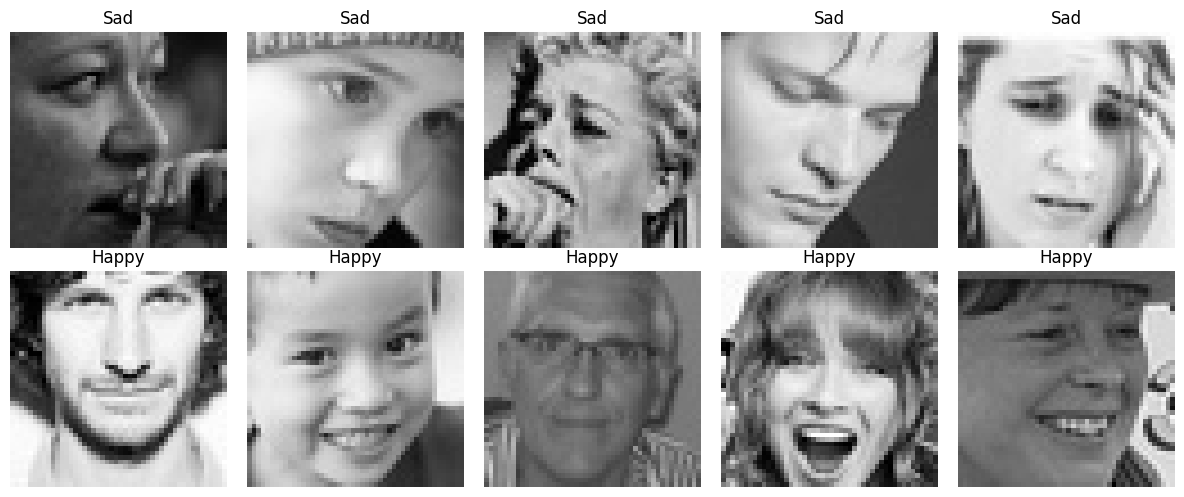

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image in zip(axes[0], sad_images[:5]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title("Sad")
    ax.axis("off")

for ax, image in zip(axes[1], happy_images[:5]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title("Happy")
    ax.axis("off")

plt.tight_layout()
plt.show()


# 6. PCA как low-dimensional representation

Используем PCA, потому что для бонуса важно не только сжать изображения, но и иметь возможность выполнить обратное преобразование:

$$
x \rightarrow z \rightarrow \hat{x}
$$

где:

- `x` — исходное изображение;
- `z` — low-dimensional representation;
- `x_hat` — реконструированное изображение.


In [8]:
start = time.perf_counter()

pca = PCA(
    n_components=N_COMPONENTS,
    random_state=RANDOM_STATE,
)

Z_faces = pca.fit_transform(X_faces)

pca_fit_time = time.perf_counter() - start

print("Исходная размерность:", X_faces.shape[1])
print("Размерность представления:", Z_faces.shape[1])
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA fit time: {pca_fit_time:.3f} sec")


Исходная размерность: 2304
Размерность представления: 100
Explained variance: 0.9061
PCA fit time: 0.226 sec


# 7. Средние представления Sad и Happy

Переходим из изображения в latent space и рассчитываем центры классов.


In [9]:
Z_sad = Z_faces[y_faces == SAD_CLASS]
Z_happy = Z_faces[y_faces == HAPPY_CLASS]

mean_sad = Z_sad.mean(axis=0)
mean_happy = Z_happy.mean(axis=0)

print("Sad latent shape:", Z_sad.shape)
print("Happy latent shape:", Z_happy.shape)


Sad latent shape: (1000, 100)
Happy latent shape: (1000, 100)


# 8. Проверка реконструкции без изменения эмоции

Сначала убедимся, что сама схема:

`image → PCA → inverse PCA`

работает корректно.



In [10]:
# Берём по одному примеру каждого класса.

sad_index = 0
happy_index = 0

sad_original = sad_vectors[sad_index]
happy_original = happy_vectors[happy_index]

sad_latent = pca.transform(
    sad_original.reshape(1, -1)
)[0]

happy_latent = pca.transform(
    happy_original.reshape(1, -1)
)[0]

sad_reconstructed = pca.inverse_transform(
    sad_latent.reshape(1, -1)
)[0]

happy_reconstructed = pca.inverse_transform(
    happy_latent.reshape(1, -1)
)[0]

sad_error = np.sqrt(
    mean_squared_error(sad_original, sad_reconstructed)
)

happy_error = np.sqrt(
    mean_squared_error(happy_original, happy_reconstructed)
)

print(f"Sad reconstruction RMSE: {sad_error:.6f}")
print(f"Happy reconstruction RMSE: {happy_error:.6f}")


Sad reconstruction RMSE: 0.074505
Happy reconstruction RMSE: 0.096816


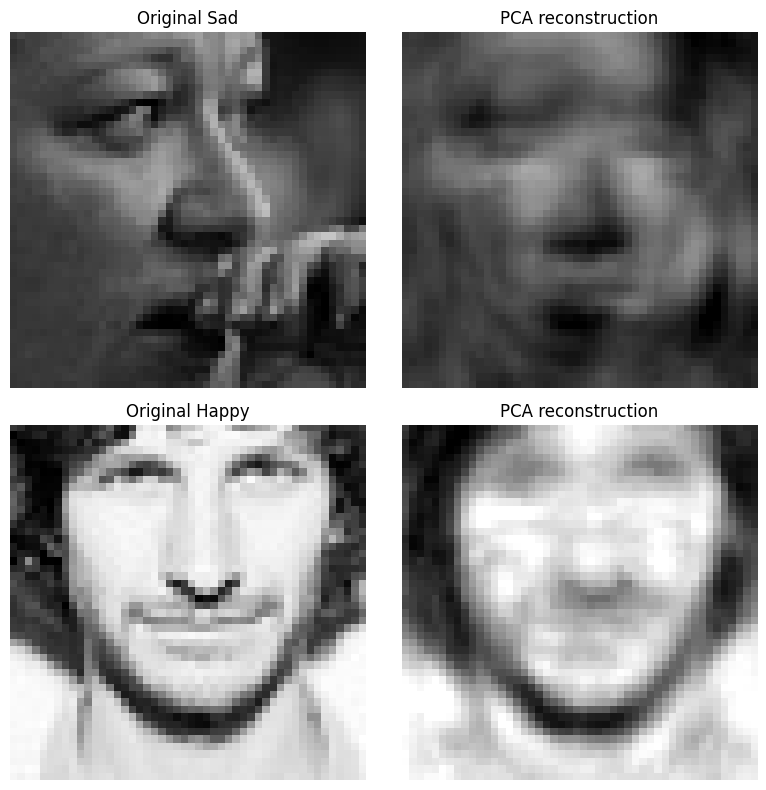

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(vector_to_image(sad_original), cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original Sad")
axes[0, 0].axis("off")

axes[0, 1].imshow(vector_to_image(sad_reconstructed), cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("PCA reconstruction")
axes[0, 1].axis("off")

axes[1, 0].imshow(vector_to_image(happy_original), cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Original Happy")
axes[1, 0].axis("off")

axes[1, 1].imshow(vector_to_image(happy_reconstructed), cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("PCA reconstruction")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


# 9. Sad → Happy

Согласно идее бонусного задания:

$$
z' = z_{sad} - \mu_{sad} + \mu_{happy}
$$

То есть из представления конкретного грустного лица убираем средний «sad direction» и добавляем средний «happy direction».

После этого выполняем обратное PCA-преобразование.


In [12]:
sad_to_happy_latent = (
    sad_latent
    - mean_sad
    + mean_happy
)

sad_to_happy = pca.inverse_transform(
    sad_to_happy_latent.reshape(1, -1)
)[0]

sad_to_happy_image = vector_to_image(sad_to_happy)

print("Sad → Happy преобразование выполнено.")


Sad → Happy преобразование выполнено.


# 10. Happy → Sad

Аналогично:

$$
z' = z_{happy} - \mu_{happy} + \mu_{sad}
$$


In [13]:
happy_to_sad_latent = (
    happy_latent
    - mean_happy
    + mean_sad
)

happy_to_sad = pca.inverse_transform(
    happy_to_sad_latent.reshape(1, -1)
)[0]

happy_to_sad_image = vector_to_image(happy_to_sad)

print("Happy → Sad преобразование выполнено.")


Happy → Sad преобразование выполнено.


# 11. Визуализация преобразований

Главный результат bonus — показать:

- исходное грустное лицо;
- его преобразованную версию в сторону smile/happy;
- исходное улыбающееся лицо;
- его преобразованную версию в сторону sad.


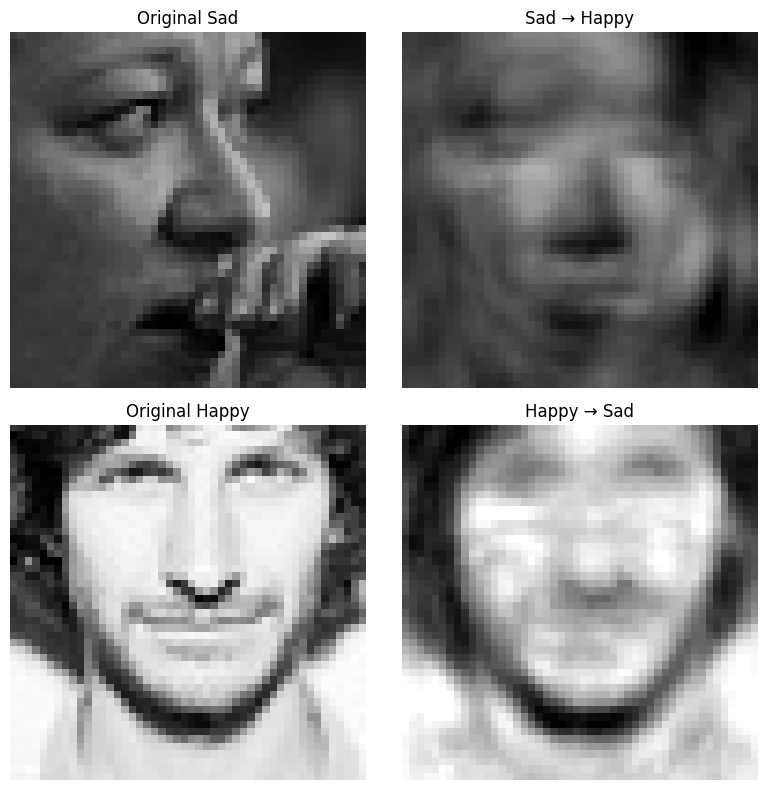

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(vector_to_image(sad_original), cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original Sad")
axes[0, 0].axis("off")

axes[0, 1].imshow(sad_to_happy_image, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("Sad → Happy")
axes[0, 1].axis("off")

axes[1, 0].imshow(vector_to_image(happy_original), cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Original Happy")
axes[1, 0].axis("off")

axes[1, 1].imshow(happy_to_sad_image, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("Happy → Sad")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


# 12. Более надёжная демонстрация: несколько лиц

Один пример может случайно оказаться неудачным. Поэтому применяем то же преобразование к нескольким лицам каждого класса.


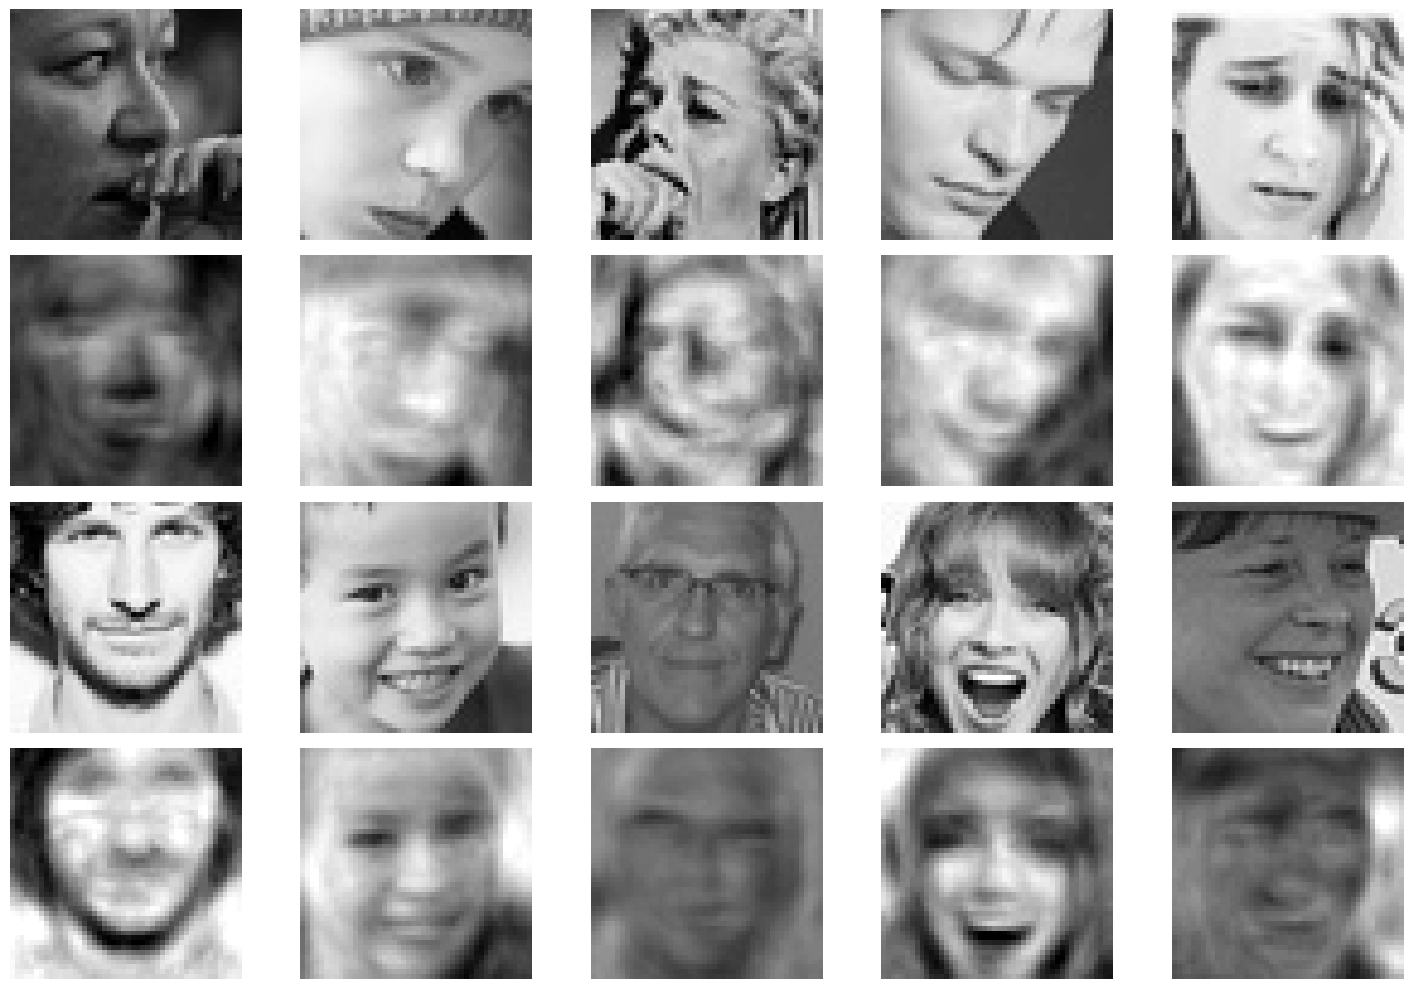

In [15]:
N_EXAMPLES = min(5, len(sad_vectors), len(happy_vectors))

fig, axes = plt.subplots(
    4,
    N_EXAMPLES,
    figsize=(3 * N_EXAMPLES, 10),
)

if N_EXAMPLES == 1:
    axes = np.asarray(axes).reshape(4, 1)

for i in range(N_EXAMPLES):
    sad_vec = sad_vectors[i]

    sad_z = pca.transform(
        sad_vec.reshape(1, -1)
    )[0]

    transformed = (
        sad_z
        - mean_sad
        + mean_happy
    )

    result = pca.inverse_transform(
        transformed.reshape(1, -1)
    )[0]

    axes[0, i].imshow(
        vector_to_image(sad_vec),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        vector_to_image(result),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[1, i].axis("off")

    happy_vec = happy_vectors[i]

    happy_z = pca.transform(
        happy_vec.reshape(1, -1)
    )[0]

    transformed = (
        happy_z
        - mean_happy
        + mean_sad
    )

    result = pca.inverse_transform(
        transformed.reshape(1, -1)
    )[0]

    axes[2, i].imshow(
        vector_to_image(happy_vec),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[2, i].axis("off")

    axes[3, i].imshow(
        vector_to_image(result),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[3, i].axis("off")

axes[0, 0].set_ylabel("Sad")
axes[1, 0].set_ylabel("Sad → Happy")
axes[2, 0].set_ylabel("Happy")
axes[3, 0].set_ylabel("Happy → Sad")

plt.tight_layout()
plt.show()


# 13. Контроль изменения latent representation

Полезно отдельно посмотреть, насколько изменился вектор после переноса между средними представлениями.



In [16]:
sad_shift = mean_happy - mean_sad
happy_shift = mean_sad - mean_happy

print("Норма Sad → Happy shift:", np.linalg.norm(sad_shift))
print("Норма Happy → Sad shift:", np.linalg.norm(happy_shift))
print("Разница между shift:", np.linalg.norm(sad_shift + happy_shift))


Норма Sad → Happy shift: 1.6340126
Норма Happy → Sad shift: 1.6340126
Разница между shift: 0.0


# 14. Вывод

В этом бонусном эксперименте PCA используется не только для сжатия лиц, но и как пространство представлений.

Основная операция:

$$
z_{source} - \mu_{source} + \mu_{target}
$$

пытается сохранить индивидуальные особенности конкретного лица, одновременно смещая его representation в сторону среднего представления другой эмоции.

Успешность эксперимента оценивается прежде всего визуально: после реконструкции должны проявляться признаки целевой эмоции, насколько это позволяет выбранное PCA-представление и качество исходных данных.

Это экспериментальный bonus, поэтому преобразование не гарантирует реалистичного результата для каждого отдельного лица.


# Контрольный список Bonus

- [x] Face Expression Recognition Dataset
- [x] выбраны классы `sad` и `happy`
- [x] лица переведены в grayscale
- [x] изображения приведены к единому размеру
- [x] изображения представлены векторами
- [x] PCA обучена
- [x] получены low-dimensional representations
- [x] рассчитано среднее представление sad
- [x] рассчитано среднее представление happy
- [x] Sad → Happy
- [x] Happy → Sad
- [x] выполнена обратная реконструкция
- [x] построена визуальная демонстрация
